# Assignment 5 - Natalie Seah
### Do all four questions.

**1.** Let's review some basic matrix multiplication. When you have an $M \times N$ matrix $A$ with $M$ rows and $N$ columns, 
$$
A= \left[ \begin{array}{cccc} a_{11} & a_{12} & ... & a_{1N} \\
a_{21} & a_{22} & ... & a_{2N} \\
\vdots & \vdots & ... & \vdots \\
a_{M1} & a_{M2} & ... & a_{MN} 
\end{array} \right],
$$
and you right-multiply it by a vector
$$
x = \left[ \begin{array}{c} x_1 \\ x_2 \\ \vdots \\ x_N 
\end{array} \right],
$$
you get
$$
Ax = \left[ \begin{array}{c} \sum_{i=1}^N a_{1i} x_i \\ \sum_{i=1}^N a_{2i} x_i \\ \vdots \\ \sum_{i=1}^N a_{Mi} x_i 
\end{array} \right].
$$
This is just "matrix row times column vector" element-by-element, stacking the results into a new vector.

For this to make sense, $N$ must be the same for the matrix and the vector, but $M$ can be different from $N$. 

Let's play with some NumPy to see this. First we'll define a matrix $A$:

In [3]:
import numpy as np

A = np.array([ [1,2,3],
              [4,5,6],
              [7,8,9]])
A

array([[1, 2, 3],
       [4, 5, 6],
       [7, 8, 9]])

a. Multiply $A$ times each of the following vectors using the @ operator. Explain which part of the $A$ matrix gets selected and explain why, using the definition of matrix multiplication. 

In [17]:
e_1 = np.array([1,0,0])
e_2 = np.array([0,1,0])
e_3 = np.array([0,0,1])

print(A @ e_1)
print(A @ e_2)
print(A @ e_3)

[1 4 7]
[2 5 8]
[3 6 9]


Matrix multiplication is defined by taking each row of the matrix and multiplying it element-by-element with the entries of the vector (or with the corresponding column of another matrix), then adding up those products to get one number. Each of these sums becomes an entry in the resulting product.

Each vector ei has a 1 in one position and 0 in all others. Because of the definition of matrix multiplication, when A@ei is computed, only the column of A corresponding to the position of the 1 in ei contributes to the result. All other entries in ei are 0, so they contribute nothing to the sum. Thus, 
A@ei selects the i-th column of A.

b. Now multiply $A$ times $u = (1,1,1)$. Explain the logic of the result with the definition of matrix multiplication.

In [18]:
u = np.ones(3)

A @ u

array([ 6., 15., 24.])

Matrix multiplication is defined by taking each row of the matrix and multiplying it element-by-element with the entries of the vector (or with the corresponding column of another matrix), then adding up those products to get one number. Each of these sums becomes an entry in the resulting product.Because u is all ones, each dot product just sums the entries of the corresponding row of A. This means that each entry of the result is the sum of the row entries since you multiply each row entry by 1 and add.

c. Whenever a matrix has 1's on the diagonal and zeros everywhere else, we call it an **identity matrix**. What happens when you multiple $A$ times $x$ below? What happens when you multiple an identity matrix times any vector? Explain your result with the definition of matrix multiplication.

In [19]:
A = np.array([ [1,0,0],
              [0,1,0],
              [0,0,1]])
x = np.array([-2,4,11])

A@x


array([-2,  4, 11])

Matrix multiplication is defined by taking each row of the matrix and multiplying it element-by-element with the entries of the vector (or with the corresponding column of another matrix), then adding up those products to get one number. Each of these sums becomes an entry in the resulting product. Each row of the identity matrix has a single 1 in the diagonal position and 0 elsewhere, so the dot product with x picks the corresponding component of 
x. This is why multiplying by the identity leaves any vector unchanged.

d. What if every row and column sum to 1, but the 1's are no longer on the diagonal? Multiple $A$ times $X$ below and explain the result. Create another matrix whose rows and columns sum to 1, but is not an identity matrix, and show how it permutes the values of $x$. 

In [20]:
A = np.array([ [0,0,1],
              [1,0,0],
              [0,1,0]])
x = np.array([-2,4,11])

A@x


array([11, -2,  4])

Each row of the matrix has a single 1 in a different column and 0’s everywhere else. Because of the definition of matrix multiplication, where each entry of the result is the dot product of one row of the matrix with the vector x each row “picks out” the element of x in the column where the 1 appears.This means the result is just a reordering of the entries of 
x, in this case [x3,x1,x2].

In [21]:
B = np.array([[0, 1, 0],
              [0, 0, 1],
              [1, 0, 0]])

print(B @ x)

[ 4 11 -2]


This one permutes the values of x into [x2,x3,x1]

e. The next matrix $A$ could be a Markov transition matrix: Its columns sum to 1, and each entry $a_{ij}$ can be interpreted as the proportion of observations who moved from state $j$ to state $i$. Multiply $A$ by each of the vectors $e_1$, $e_2$, and $e_3$, and explain your results.

In [22]:
rng = np.random.default_rng(100)
A = rng.random((3,3)) # Generate a random 3X3 matrix
sums = np.sum(A,axis=0) # Column sums
A = A/sums # Normalize the columns so they sum to 1
print(A)

[[0.50052958 0.24049286 0.18358131]
 [0.02574731 0.39251588 0.37907577]
 [0.47372311 0.36699127 0.43734292]]


In [23]:
print(A @ e_1)
print(A @ e_2)
print(A @ e_3)

[0.50052958 0.02574731 0.47372311]
[0.24049286 0.39251588 0.36699127]
[0.18358131 0.37907577 0.43734292]


Multiplying by ei picks out the i-th column of the Markov matrix because because ei has 1 in position i and 0 elsewhere. Each entry of that column represents the proportion of observations that transition from state i (the starting state) to each of the states.

f. For each of the vectors $e_1, e_2, e_3$, multiple $A$ times that vector 5 times. What answer do you get for each starting vector? Describe the behavior you observe.

In [25]:
v1 = e_1
v2 = e_2
v3 = e_3

for _ in range(5):
    v1 = A @ v1
    v2 = A @ v2
    v3 = A @ v3

print(v1)
print(v2)
print(v3)


[0.29266551 0.27862515 0.42870935]
[0.29197422 0.27979983 0.42822595]
[0.29171646 0.2802254  0.42805814]


All three resulting vectors are very similar, even though they started from different states. Each entry is a weighted sum of the previous vector’s entries according to the transition probabilities. After multiple iterations, these sums converge, so the vectors approach the same long-term distribution regardless of the starting state.

*2.* Let's consider a simple Markov transition matrix over two states:
$$
T = \left[ \begin{array}{cc} p_{1\leftarrow 1} &  p_{1\leftarrow 2} \\
p_{2 \leftarrow 1} & p_{2 \leftarrow 2} \end{array}\right] 
$$
The arrows help visualize the transition a bit: This is the same index notation as usual, $p_{ij}$, but writing it $p_{i \leftarrow j}$ emphasizes that it's the proportion of times that state $j$ transitions to state $i$. Below, $T$ is given by
$$
T = \left[ \begin{array}{cc} .25 & .5 \\
.75 & .5 \end{array}\right].
$$

- Start in state 1, at the initial condition $[1,0]$. Multiply that vector by $T$. Write out the result in terms of the formula and compute the result in a code chunk below. What is this object you're looking at, in terms of proportions and transitions?
- Multiple by $T$ again. What do you get? This isn't a column of $T$. Explain in words what it is. (Hint: A forecast of what in what period?)
- Keep multiplying the current vector of outcomes by $T$. When does it start to settle down without changing further?
- Do the above analysis again, starting from the initial condition $[0,1]$. Do you get a different result?
- The take-away is that, in the long run, these chains settle down into the long-run proportions, and the sensitivity on initial conditions vanishes. 


In [15]:
T = np.array([[ 1/4, 1/2],
                 [ 3/4, 1/2 ]])


In [ ]:
init_condition = np.array([1,0])    

p_1 = T@init_condition
print(p_1)


[1 0]
[0.25 0.75]


$$
x_1 = 
\Big[
x_1 \cdot p_{1 \leftarrow 1} + x_2 \cdot p_{1 \leftarrow 2}, \;\;
x_1 \cdot p_{2 \leftarrow 1} + x_2 \cdot p_{2 \leftarrow 2}
\Big]
=
[1 \cdot 0.25 + 0 \cdot 0.5, \;\; 1 \cdot 0.75 + 0 \cdot 0.5]
=
[0.25, 0.75]
$$

After one step, there is a 25% chance to be in state 1 and a 75% chance to be in state 2. This object is the one-step forecast of the state proportions, as it shows the probabilities of being in each state after one transition, given the initial condition.

In [11]:
p_2 = T@p_1
print(p_2)

#should be .4375 .5625

[0.4375 0.5625]


This is a forecast of the probability of being in each state two periods ahead. It shows the probabilities of being in state 1 or state 2 in period 2, starting from period 0 in state 1. It is not a column of T, because it depends on the initial condition and the transition dynamics.

In [55]:
n = 100
p = np.array([1,0])
for t in range(n):
    print(p)
    p = T@p

[1 0]
[0.25 0.75]
[0.4375 0.5625]
[0.390625 0.609375]
[0.40234375 0.59765625]
[0.39941406 0.60058594]
[0.40014648 0.59985352]
[0.39996338 0.60003662]
[0.40000916 0.59999084]
[0.39999771 0.60000229]
[0.40000057 0.59999943]
[0.39999986 0.60000014]
[0.40000004 0.59999996]
[0.39999999 0.60000001]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0

It starts to settle down without changing any further around the 13th step.

In [16]:
n = 100
p = np.array([0,1])
for t in range(n):
    print(p)
    p = T@p

[0 1]
[0.5 0.5]
[0.375 0.625]
[0.40625 0.59375]
[0.3984375 0.6015625]
[0.40039062 0.59960938]
[0.39990234 0.60009766]
[0.40002441 0.59997559]
[0.3999939 0.6000061]
[0.40000153 0.59999847]
[0.39999962 0.60000038]
[0.4000001 0.5999999]
[0.39999998 0.60000002]
[0.40000001 0.59999999]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6

The long-run probabilities [0.4, 0.6] are the same as starting from [1, 0].This confirms that the stationary distribution is independent of the initial condition.

From class:

In [57]:
n = 100
state = 0
sim = []
for t in range(n):
    sim.append(state)
    prob = T[:,state]
    state  = np.random.choice(a = [0,1],p = prob)

In [58]:
sim


[0,
 np.int64(0),
 np.int64(1),
 np.int64(1),
 np.int64(1),
 np.int64(0),
 np.int64(1),
 np.int64(1),
 np.int64(0),
 np.int64(1),
 np.int64(0),
 np.int64(1),
 np.int64(0),
 np.int64(0),
 np.int64(1),
 np.int64(1),
 np.int64(1),
 np.int64(0),
 np.int64(1),
 np.int64(1),
 np.int64(0),
 np.int64(1),
 np.int64(1),
 np.int64(0),
 np.int64(1),
 np.int64(0),
 np.int64(0),
 np.int64(1),
 np.int64(1),
 np.int64(0),
 np.int64(1),
 np.int64(0),
 np.int64(1),
 np.int64(1),
 np.int64(1),
 np.int64(1),
 np.int64(0),
 np.int64(1),
 np.int64(0),
 np.int64(0),
 np.int64(1),
 np.int64(1),
 np.int64(0),
 np.int64(1),
 np.int64(0),
 np.int64(0),
 np.int64(1),
 np.int64(1),
 np.int64(1),
 np.int64(0),
 np.int64(0),
 np.int64(1),
 np.int64(0),
 np.int64(1),
 np.int64(1),
 np.int64(0),
 np.int64(1),
 np.int64(0),
 np.int64(1),
 np.int64(0),
 np.int64(1),
 np.int64(1),
 np.int64(0),
 np.int64(1),
 np.int64(1),
 np.int64(0),
 np.int64(1),
 np.int64(0),
 np.int64(1),
 np.int64(1),
 np.int64(0),
 np.int64(0),
 n

In [ ]:
x = np.array(sim)
np.mean(x)

#long run average of sunny days

np.float64(0.58)

3. Weather data

- Load the `cville_weather.csv` data. This includes data from Jan 4, 2024 to Feb 2, 2025. Are there any missing data issues?
- Based on the precipitation variable, `PRCP`, make a new variable called `rain` that takes the value 1 if `PRCP`>0 and 0 otherwise.
- Build a two-state Markov chain over the states 0 and 1 for the `rain` variable. 
- For your chain from c, how likely is it to rain if it was rainy yesterday? How likely is it to rain if it was clear yesterday?
- Starting from a clear day, forecast the distribution. How quickly does it converge to a fixed result? What if you start from a rainy day?
- Conditional on being rainy, plot a KDE of the `PRCP` variable.
- Describe one way of making your model better for forecasting and simulation the weather.

Congratulations, you now are a non-parametric meteorologist!

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [45]:
df = pd.read_csv("/Users/natalieseah/Desktop/UnderstandingUncertainty/UnderstandingUncertaintySeah/cville_weather.csv")

df.head()


,STATION,NAME,DATE,DAPR,DAPR_ATTRIBUTES,MDPR,MDPR_ATTRIBUTES,PRCP,PRCP_ATTRIBUTES,SNOW,SNOW_ATTRIBUTES,SNWD,SNWD_ATTRIBUTES
0,US1VACRC002,"CHARLOTTESVILLE 0.5 NNE, VA US",2024-01-04,NaN,NaN,NaN,NaN,0.03,",,N",NaN,NaN,NaN,NaN
1,US1VACRC002,"CHARLOTTESVILLE 0.5 NNE, VA US",2024-01-07,NaN,NaN,NaN,NaN,1.08,",,N",NaN,NaN,NaN,NaN
2,US1VACRC002,"CHARLOTTESVILLE 0.5 NNE, VA US",2024-01-09,NaN,NaN,NaN,NaN,0.24,",,N",NaN,NaN,NaN,NaN
3,US1VACRC002,"CHARLOTTESVILLE 0.5 NNE, VA US",2024-01-10,NaN,NaN,NaN,NaN,3.00,",,N",NaN,NaN,NaN,NaN
4,US1VACRC002,"CHARLOTTESVILLE 0.5 NNE, VA US",2024-01-24,NaN,NaN,NaN,NaN,0.00,",,N",0.0,",,N",NaN,NaN


In [34]:
print(df.isna().sum())

STATION              0
NAME                 0
DATE                 0
DAPR               399
DAPR_ATTRIBUTES    399
MDPR               399
MDPR_ATTRIBUTES    399
PRCP                12
PRCP_ATTRIBUTES     12
SNOW               188
SNOW_ATTRIBUTES    188
SNWD               410
SNWD_ATTRIBUTES    410
dtype: int64


There are some missing data issues, as certain columns don't have any data for pretty much all of the rows. SNWD and SNWD_ATTRIBUTES as well as DAPR, DAPR_ATTRIBUTES, MDPR, MDPR_ATTRIBUTES are mostly made up of NAs and SNOW and SNOW_ATTRIBUTES also has a large chunk of missing data. It does seem like these aren't the columns we are using for this question though, so the main problem here might be that PRCP has 12 missing values that need to be handled.

Based on the precipitation variable, `PRCP`, make a new variable called `rain` that takes the value 1 if `PRCP`>0 and 0 otherwise:

In [46]:
df['PRCP'] = df['PRCP'].fillna(0)

df['rain'] = (df['PRCP'] > 0).astype(int)

Build a two-state Markov chain over the states 0 and 1 for the `rain` variable:

In [47]:
df['rain_lag'] = df['rain'].shift(1) #val from yesterday

# Remove first row b/c it doesn't have a yesterday
df.dropna(subset=['rain_lag'], inplace=True)

transitions = pd.crosstab(df['rain_lag'], df['rain'], normalize='index')
print(transitions)

rain             0         1
rain_lag                    
0.0       0.731602  0.268398
1.0       0.351955  0.648045


For your chain from c, how likely is it to rain if it was rainy yesterday? How likely is it to rain if it was clear yesterday?:

From my chain above, if yesterday was rainy, there's a 64.8% chance of rain today. If yesterday was clear, there's a 26.8% chance of rain today.

Starting from a clear day, forecast the distribution. How quickly does it converge to a fixed result?:

In [43]:
P = transitions.to_numpy()  
# Starting from clear day
state = np.array([1, 0])  

for _ in range(10):
    state = state @ P
    print(state)

[0.73160173 0.26839827]
[0.62970529 0.37029471]
[0.59102067 0.40897933]
[0.57633419 0.42366581]
[0.57075852 0.42924148]
[0.56864174 0.43135826]
[0.56783811 0.43216189]
[0.56753302 0.43246698]
[0.56741719 0.43258281]
[0.56737321 0.43262679]


It coverges to a pretty fixed result around the 6th/7th iteration.

What if you start from a rainy day?

In [ ]:
P = transitions.to_numpy()  
#start from rainy day
state = np.array([0, 1])  

for _ in range(10):
    state = state @ P
    print(state)

[0.35195531 0.64804469]
[0.48557388 0.51442612]
[0.5363017 0.4636983]
[0.55556033 0.44443967]
[0.5628718 0.4371282]
[0.56564757 0.43435243]
[0.56670139 0.43329861]
[0.56710146 0.43289854]
[0.56725335 0.43274665]
[0.56731101 0.43268899]


This one also coverges to a fixed result around the 6th/7th iteration.

Conditional on being rainy, plot a KDE of the `PRCP` variable:

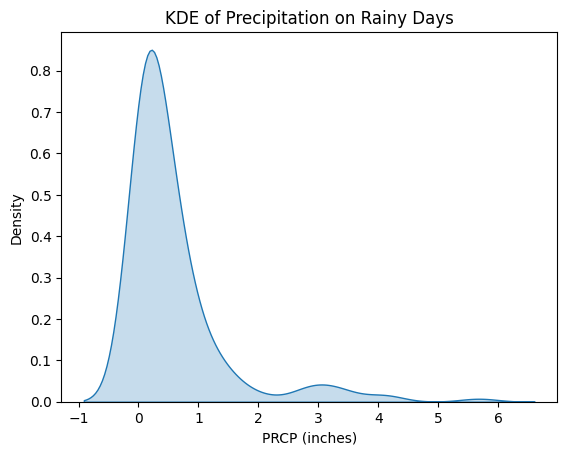

In [45]:
rainy_prcp = df[df['rain'] == 1]['PRCP']

sns.kdeplot(rainy_prcp, fill=True)
plt.xlabel("PRCP (inches)")
plt.title("KDE of Precipitation on Rainy Days")
plt.show()

Describe one way of making your model better for forecasting and simulation the weather:

One way to improve the model would be to include seasonal effects or temperature as additional states or covariates. For instance, rain is more likely in some months than others, so a time-varying Markov chain or a hidden Markov model could capture that structure.

4. Taxicab trajectories: Using the pickled taxicab data, we want to complete the exercise from class.

- For the taxicab trajectory data, determine your state space and clean your sequences of cab rides.
- Compute the transition matrix for the taxicab data between neighborhoods in Manhattan. Plot it in a heat map. What are the most common routes?
- Explain why taxicabs are most likely order 1, and not 2 or more.
- Starting at Hell's Kitchen, create a sequence of forecasts of where the cab is likely to be in 2, 3, 5, and 10 trips
- Starting at any neighborhood, iterate your forecast until it is no longer changing very much. Where do cabs spend most of their time working in Manhattan?

In [19]:
import numpy as no
import pandas as pd
import seaborn as sns
import pickle

with open('taxicab.pkl','rb') as f:
    data = pickle.load(f)
    
print(len(data))

data[0]


1000


0     Outside Manhattan
0     Outside Manhattan
0     Outside Manhattan
0     Outside Manhattan
0     Outside Manhattan
            ...        
29                 SoHo
29                 SoHo
13    Greenwich Village
3               Chelsea
3               Chelsea
Name: nbhd, Length: 26026, dtype: object

For the taxicab trajectory data, determine your state space and clean your sequences of cab rides:

In [50]:
clean_data = []
for trip in data:
    trip = [x.strip() for x in trip if x]
    if len(trip) > 1:
        clean_data.append(trip)
        
        
states = set(clean_data[0])
for i in range(1, len(clean_data)):
    new_trip = clean_data[i]
    new_states = set(new_trip)
    states = states.union(new_states)
states = list(states)

print(len(states))
print(states)

38
['Greenwich Village', "Hell's Kitchen", 'Washington Heights', 'Battery Park City', 'Liberty Island', 'Ellis Island', 'Theater District', 'Nolita', 'East Harlem', 'Flatiron District', 'Stuyvesant Town', 'Civic Center', 'West Village', 'Inwood', 'Roosevelt Island', 'Lower East Side', 'Midtown', 'Harlem', 'Kips Bay', 'East Village', 'Marble Hill', 'NoHo', 'Governors Island', 'SoHo', "Randall's Island", 'Murray Hill', 'Chinatown', 'Upper West Side', 'Outside Manhattan', 'Financial District', 'Central Park', 'Little Italy', 'Morningside Heights', 'Gramercy', 'Chelsea', 'Tribeca', 'Two Bridges', 'Upper East Side']


In [28]:
#figure out what state space is

states = set(data[0])

for i in range(1, len(data)):
    new_trip = data[i]
    new_states = set(new_trip)
    states = states.union(new_states)
states = list(states)

print(states)

['Greenwich Village', "Hell's Kitchen", 'Washington Heights', 'Battery Park City', 'Liberty Island', 'Ellis Island', 'Theater District', 'Nolita', 'East Harlem', 'Flatiron District', 'Stuyvesant Town', 'Civic Center', 'West Village', 'Inwood', 'Roosevelt Island', 'Lower East Side', 'Midtown', 'Harlem', 'Kips Bay', 'East Village', 'Marble Hill', 'NoHo', 'Governors Island', 'SoHo', "Randall's Island", 'Murray Hill', 'Chinatown', 'Upper West Side', 'Outside Manhattan', 'Financial District', 'Central Park', 'Little Italy', 'Morningside Heights', 'Gramercy', 'Chelsea', 'Tribeca', 'Two Bridges', 'Upper East Side']


In [ ]:
#how long is state space? 38 so we need a 38 by 38 matrix to track our transitions
tr_counts = np.zeros( (len(states),len(states)))
for trip in data:
    seq = np.array(trip)
    for t in range(1,len(seq)):
        x_tm1 = seq[t-1]
        x_t = seq[t]
        index_from = states.index(x_tm1)
        index_to = states.index(x_t)
        tr_counts[index_to,index_from] += 1
        
tr_counts
        

array([[1.119300e+05, 1.213500e+04, 3.200000e+02, ..., 1.268800e+04,
        1.520000e+02, 1.831200e+04],
       [1.227300e+04, 3.463220e+05, 5.315000e+03, ..., 1.037100e+04,
        1.130000e+02, 4.910700e+04],
       [7.790000e+02, 5.539000e+03, 1.123400e+04, ..., 5.140000e+02,
        9.000000e+00, 6.048000e+03],
       ...,
       [9.970000e+03, 1.045400e+04, 2.460000e+02, ..., 1.019760e+05,
        4.710000e+02, 1.057900e+04],
       [1.960000e+02, 1.970000e+02, 7.000000e+00, ..., 3.180000e+02,
        8.480000e+02, 4.860000e+02],
       [1.620200e+04, 5.555700e+04, 3.685000e+03, ..., 1.027900e+04,
        2.500000e+02, 1.283151e+06]], shape=(38, 38))

In [34]:
sums = tr_counts.sum(axis=0, keepdims = True)
sums

array([[5.102590e+05, 1.224335e+06, 7.252200e+04, 2.292350e+05,
        1.000000e+00, 3.000000e+00, 8.740570e+05, 1.063810e+05,
        3.168450e+05, 3.952900e+05, 1.112820e+05, 5.791000e+04,
        8.393600e+05, 1.431100e+04, 8.010000e+03, 3.705730e+05,
        3.851989e+06, 2.171460e+05, 5.077810e+05, 8.886410e+05,
        4.930000e+02, 1.743200e+05, 1.200000e+01, 5.505930e+05,
        3.603000e+03, 6.544000e+05, 1.058700e+05, 1.803502e+06,
        2.363902e+06, 4.415730e+05, 3.701250e+05, 3.859100e+04,
        1.627100e+05, 5.017520e+05, 1.978286e+06, 4.086350e+05,
        1.038800e+04, 2.797710e+06]])

In [37]:
tr_pr = np.divide(tr_counts,sums, out = np.zeros_like(tr_counts), where = sums!=0)
tr_pr

tr_df = pd.DataFrame(np.round(tr_pr,2), index = states, columns = states)

print(tr_df)

                     Greenwich Village  Hell's Kitchen  Washington Heights  \
Greenwich Village                 0.22            0.01                0.00   
Hell's Kitchen                    0.02            0.28                0.07   
Washington Heights                0.00            0.00                0.15   
Battery Park City                 0.01            0.01                0.00   
Liberty Island                    0.00            0.00                0.00   
Ellis Island                      0.00            0.00                0.00   
Theater District                  0.02            0.08                0.02   
Nolita                            0.01            0.00                0.00   
East Harlem                       0.00            0.01                0.02   
Flatiron District                 0.02            0.01                0.00   
Stuyvesant Town                   0.01            0.00                0.00   
Civic Center                      0.00            0.00          

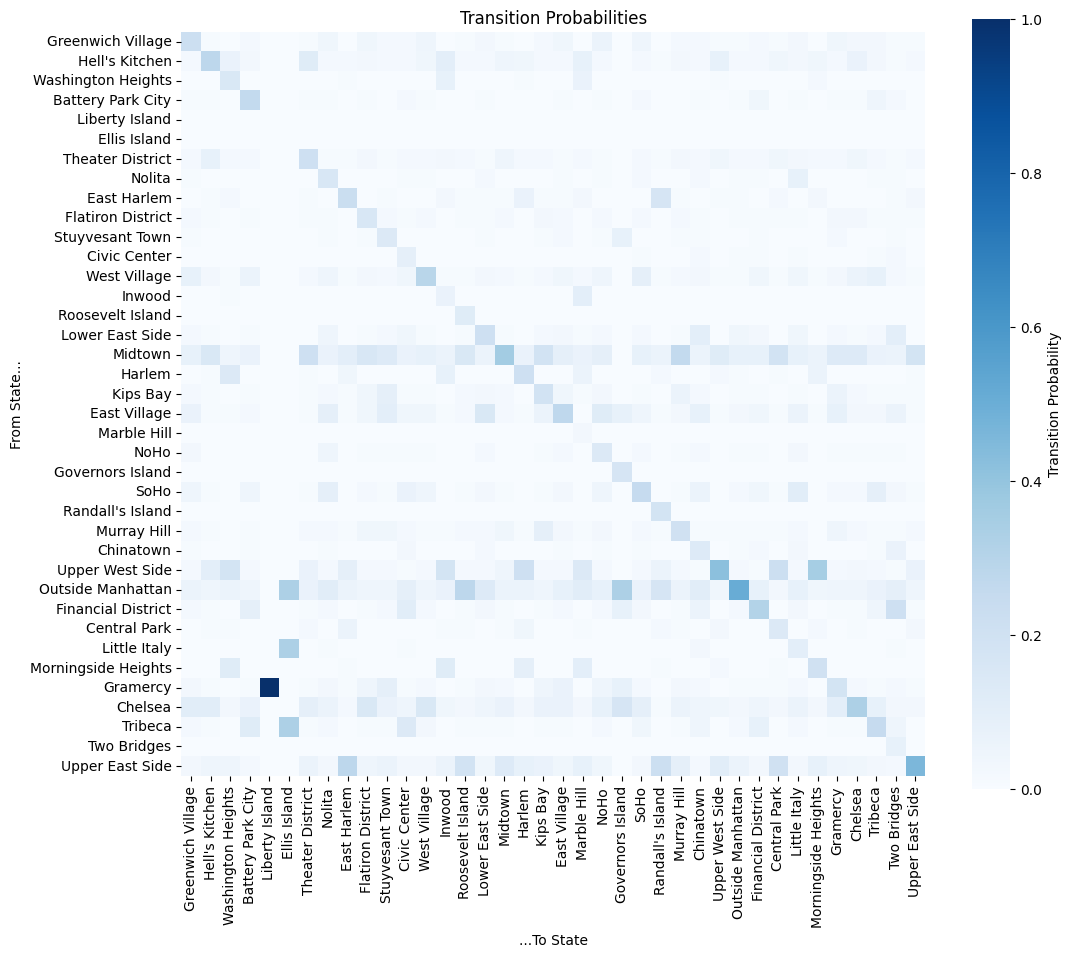

In [38]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,10))
sns.heatmap(tr_df, 
            cmap='Blues',    
            square=True,          
            xticklabels=states,
            yticklabels=states,
            cbar_kws={'label': 'Transition Probability'})

plt.title('Transition Probabilities')
plt.xlabel('...To State')
plt.ylabel('From State...')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()


The most common route is between Liberty Island and Gramercy. Many of the top transitions are also self-transitions (Outside Manhattan to Outside Manhattan, Upper East Side to Upper East Side, etc).

- Explain why taxicabs are most likely order 1, and not 2 or more.

Taxicabs are most likely order 1 because the next neighborhood they visit depends primarily on the cab’s current location, not on the full history of past locations. Once a cab finishes a trip, its next destination is determined by where it is currently waiting for passengers. Higher order models would require the next trip to depend on where the cab was two or more trips ago, which doesn't really make sense in this context.

In [53]:
#- Starting at Hell's Kitchen, create a sequence of forecasts of where the cab is likely to be in 2, 3, 5, and 10 trips

start_state = "Hell's Kitchen"

# initial probability vector
p0 = np.zeros(len(states))
p0[states.index(start_state)] = 1.0

# horizons
horizons = [2, 3, 5, 10]

for n in horizons:
    pn = np.linalg.matrix_power(tr_pr, n) @ p0
    forecast = pd.Series(pn, index=states).sort_values(ascending=False)
    
    print(f"{n} trips:")
    for loc, prob in forecast.head(5).items():
        print(f"  {loc}: {prob:.3f}")


2 trips:
  Midtown: 0.173
  Hell's Kitchen: 0.119
  Chelsea: 0.109
  Upper West Side: 0.099
  Upper East Side: 0.087
3 trips:
  Midtown: 0.173
  Upper East Side: 0.108
  Chelsea: 0.097
  Upper West Side: 0.092
  Outside Manhattan: 0.090
5 trips:
  Midtown: 0.169
  Upper East Side: 0.120
  Outside Manhattan: 0.099
  Chelsea: 0.088
  Upper West Side: 0.083
10 trips:
  Midtown: 0.168
  Upper East Side: 0.122
  Outside Manhattan: 0.103
  Chelsea: 0.086
  Upper West Side: 0.079


In [61]:
#Starting at any neighborhood, iterate your forecast until it is no longer changing very much. Where do cabs spend most of their time working in Manhattan?

start_state = 'Greenwich Village'
p = np.zeros(len(states))
p[states.index(start_state)] = 1.0  

tolerance = 1e-6
max_iterations = 100

for i in range(max_iterations):
    p_next = tr_pr @ p
    change = np.sum(np.abs(p_next - p))
    if change < tolerance:
        print(f"{i+1} iterations")
        break
    p = p_next

steady_state = pd.Series(p, index=states).sort_values(ascending=False)

for loc, prob in steady_state.head(10).items():
    print(f"  {loc}: {prob:.3f}")

26 iterations
  Midtown: 0.168
  Upper East Side: 0.122
  Outside Manhattan: 0.103
  Chelsea: 0.086
  Upper West Side: 0.079
  Hell's Kitchen: 0.053
  East Village: 0.039
  Theater District: 0.038
  West Village: 0.037
  Murray Hill: 0.028


Cabs spend most of their time working in Midtown, the Upper East Side, and Outside Manhattan.